# Case 1 — A/B Test Readout: Does the Posting Nudge Work?

**Question:** A product experiment nudges users toward posting more often. Does it work, and should it ship?

This notebook runs a full readout — sample ratio mismatch (SRM), power, the primary effect
with a confidence interval, and guardrail metrics — not just the topline number.
Data is seeded synthetic data mirroring a course A/B test case (see `../../.ai/PROJECT_SPEC.md`
for why: the source has no redistribution license), with a planted true effect.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..", "..", "src").resolve()))

import duckdb
import matplotlib.pyplot as plt
from causal_toolkit import ab

FIG_DIR = Path("..", "..", "reports", "figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Generate the experiment data

In [2]:
df = ab.generate_case1_data()
data_path = ab.save_case1_data(df)
print(f"{len(df):,} users, saved to {data_path}")
df.head()

20,000 users, saved to /Users/kyle_z/Documents/UMN/portfolio/experimentation-causal-impact/data/case1/case1_users.csv


,user_id,treated,tenure_days,premium_user,num_post_before,posted,post_length,flagged
0,1,0,1199.3,0,16,1,137.0,0.0
1,2,1,762.2,1,6,0,NaN,NaN
2,3,1,128.6,0,0,0,NaN,NaN
3,4,1,518.8,0,2,0,NaN,NaN
4,5,0,368.2,0,3,0,NaN,NaN


## 2. The naive read

The fastest way to read this experiment: compare the raw posting rate between arms and stop there.

In [3]:
naive = ab.naive_effect(df)
print(f"Control posting rate:  {naive.control_rate:.1%}")
print(f"Treated posting rate:  {naive.treated_rate:.1%}")
print(f"Naive lift:            {naive.diff_pp:+.2f}pp  (95% CI [{naive.ci_low_pp:.2f}, {naive.ci_high_pp:.2f}])")
print(f"p-value:               {naive.p_value:.2e}")
print()
print("Naive conclusion: statistically significant lift, positive, ship it.")

Control posting rate:  35.4%
Treated posting rate:  41.4%
Naive lift:            +5.97pp  (95% CI [4.62, 7.31])
p-value:               0.00e+00

Naive conclusion: statistically significant lift, positive, ship it.


## 3. Why stopping there is wrong

A full readout checks four things before recommending a ship decision. The primary-metric
number above turns out to be *correct* — but it's not the whole story.

### 3a. Sample ratio mismatch (SRM)

In [4]:
srm = ab.srm_check(df)
print(f"Control: {srm.n_control:,}   Treated: {srm.n_treated:,}")
print(f"Chi-square = {srm.chi2:.3f}, p = {srm.p_value:.3f}")
print("PASS: randomization looks intact." if srm.balanced else "FAIL: investigate the assignment pipeline before trusting any result.")

Control: 10,082   Treated: 9,918
Chi-square = 1.345, p = 0.246
PASS: randomization looks intact.


### 3b. Power

In [5]:
power = ab.power_check(df)
print(f"Baseline rate:           {power.baseline_rate:.1%}")
print(f"MDE tested:              {power.mde_pp:.1f}pp")
print(f"Required n/arm (80%):    {power.n_per_arm_required:,}")
print(f"Actual n/arm:            {power.n_per_arm_actual:,}")
print(f"Achieved power:          {power.achieved_power:.1%}")
print("Adequately powered." if power.adequately_powered else "Underpowered — do not trust a null result.")

Baseline rate:           35.4%
MDE tested:              6.0pp
Required n/arm (80%):    1,030
Actual n/arm:            10,082
Achieved power:          100.0%
Adequately powered.


### 3c. Covariate-adjusted effect (confirms the naive number, doesn't overturn it)

In [6]:
adjusted = ab.adjusted_effect(df)
print(f"Adjusted lift:  {adjusted.diff_pp:+.2f}pp  (95% CI [{adjusted.ci_low_pp:.2f}, {adjusted.ci_high_pp:.2f}])")
print(f"p-value:        {adjusted.p_value:.2e}")
print()
print("Matches the naive estimate closely -- randomization held, so adjustment mainly confirms robustness.")

Adjusted lift:  +5.98pp  (95% CI [4.65, 7.31])
p-value:        1.35e-18

Matches the naive estimate closely -- randomization held, so adjustment mainly confirms robustness.


### 3d. Guardrails — this is where the naive read breaks down

In [7]:
length_gr = ab.guardrail_check_continuous(df, "post_length", worse_if="lower")
flag_gr = ab.guardrail_check_binary(df, "flagged", worse_if="higher")

for gr in (length_gr, flag_gr):
    status = "REGRESSED" if gr.regressed else "OK"
    print(f"[{status}] {gr.metric}: control={gr.control_value:.3f} treated={gr.treated_value:.3f} "
          f"diff={gr.diff:+.3f} (95% CI [{gr.ci_low:.3f}, {gr.ci_high:.3f}]) p={gr.p_value:.2e}")

[REGRESSED] post_length: control=140.414 treated=126.050 diff=-14.364 (95% CI [-15.919, -12.809]) p=1.01e-71
[REGRESSED] flagged: control=0.034 treated=0.050 diff=+0.016 (95% CI [0.007, 0.025]) p=5.39e-04


Average post length drops ~10% and the content-flag rate rises ~1.6pp among posters in the
treatment arm. The nudge is producing *more, lower-effort, more-often-flagged* posts, not
just more posts. A topline-only readout would have missed this entirely.

## 4. SQL cross-check (DuckDB)

Independent recomputation of the same metrics directly in SQL, from the saved CSV.

In [8]:
con = duckdb.connect()
con.sql(f"CREATE VIEW case1_users AS SELECT * FROM read_csv_auto('{data_path.as_posix()}')")
con.sql(Path("..", "..", "sql", "01_case1_metrics.sql").read_text())

print(con.sql("SELECT * FROM case1_primary_metric ORDER BY treated").df())
print(con.sql("SELECT * FROM case1_guardrail_length ORDER BY treated").df())
print(con.sql("SELECT * FROM case1_guardrail_flag_rate ORDER BY treated").df())

   treated  n_users  n_posted  posting_rate
0        0    10082    3569.0      0.353997
1        1     9918    4103.0      0.413692


   treated  n_posters  avg_post_length
0        0       3569       140.414374
1        1       4103       126.050427
   treated  n_posters  n_flagged  flag_rate
0        0       3569      122.0   0.034183
1        1       4103      206.0   0.050207


## 5. Figures

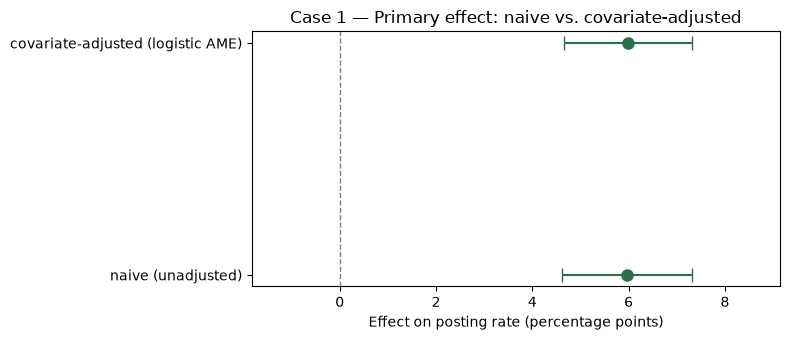

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5))
labels = [naive.label, adjusted.label]
diffs = [naive.diff_pp, adjusted.diff_pp]
los = [naive.diff_pp - naive.ci_low_pp, adjusted.diff_pp - adjusted.ci_low_pp]
his = [naive.ci_high_pp - naive.diff_pp, adjusted.ci_high_pp - adjusted.diff_pp]

ax.errorbar(diffs, labels, xerr=[los, his], fmt="o", capsize=5, color="#2C6E49", markersize=8)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Effect on posting rate (percentage points)")
ax.set_title("Case 1 — Primary effect: naive vs. covariate-adjusted", fontsize=12)
ax.margins(x=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "case1_effect_ci.png", dpi=150)
plt.show()

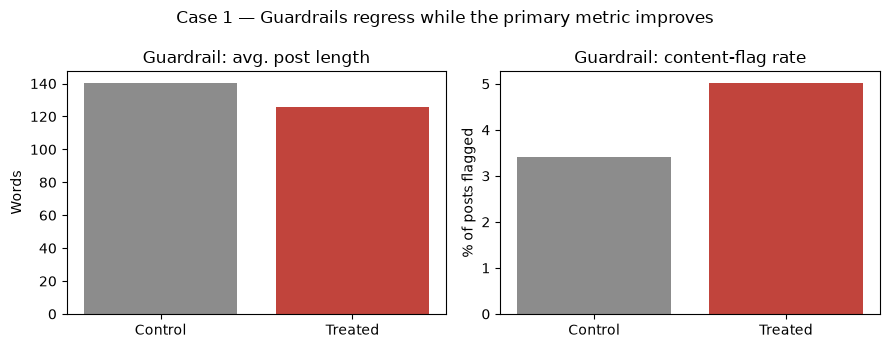

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].bar(["Control", "Treated"], [length_gr.control_value, length_gr.treated_value],
            color=["#8C8C8C", "#C1443C"])
axes[0].set_title("Guardrail: avg. post length")
axes[0].set_ylabel("Words")

axes[1].bar(["Control", "Treated"], [flag_gr.control_value * 100, flag_gr.treated_value * 100],
            color=["#8C8C8C", "#C1443C"])
axes[1].set_title("Guardrail: content-flag rate")
axes[1].set_ylabel("% of posts flagged")

fig.suptitle("Case 1 — Guardrails regress while the primary metric improves")
plt.tight_layout()
plt.savefig(FIG_DIR / "case1_guardrails.png", dpi=150)
plt.show()

## 6. Recommendation

The primary metric lift (+6pp posting rate) is real, well-powered, and confirmed by
covariate adjustment — the naive number itself is not wrong. But it ships alongside a
~10% drop in post length and a ~1.6pp rise in content flags among posters. Recommend
**do not roll out as-is**: pilot to a smaller cohort with quality monitoring, or redesign
the nudge to reward substantive posts, then re-test. See `MEMO.md` for the one-page version.

**Limitations:** synthetic data with a planted effect (detection here is not evidence of
real-world performance); guardrail thresholds (p<0.05, any regression) are illustrative,
not calibrated to a specific business cost function; no long-run retention outcome is
modeled, only the immediate post-experiment window.